### Exercise: Email Spam Classification

Objective:
The objective of this exercise is to build a machine learning model that can classify emails as "spam" or "not spam" (ham) based on their attributes.

Data:
You can use the classic "Spambase" dataset available in Scikit-learn, which contains features extracted from email texts. The dataset is already preprocessed and ready for use.

Steps:

Load the Spambase dataset from Scikit-learn.
Split the data into training and test sets.
Choose a classification algorithm (e.g., Logistic Regression, Decision Trees, or Random Forests) and create a model using Scikit-learn.
Train the model using the training data.
Evaluate the model's performance on the test data using accuracy or other appropriate metrics.
Experiment with different hyperparameters and algorithms to see how the model's performance changes.
Challenge:
For an extra challenge, try to implement and evaluate multiple classifiers (e.g., Logistic Regression, Decision Trees, and Random Forests) to compare their performance.

Hints:

Use the train_test_split function from Scikit-learn to split the dataset into training and test sets.
Create a model using the chosen classifier, fit it to the training data, and then use it to predict the labels for the test data.
Use the accuracy_score function from Scikit-learn to evaluate the model's performance on the test data.

In [3]:
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, classification_report

In [4]:
spambase = fetch_openml(name='spambase', version=1, as_frame=True)

X, y = spambase.data, spambase.target

In [6]:
print(spambase.DESCR)

**Author**: Mark Hopkins, Erik Reeber, George Forman, Jaap Suermondt    
**Source**: [UCI](https://archive.ics.uci.edu/ml/datasets/spambase)   
**Please cite**: [UCI](https://archive.ics.uci.edu/ml/citation_policy.html)

SPAM E-mail Database  
The "spam" concept is diverse: advertisements for products/websites, make money fast schemes, chain letters, pornography... Our collection of spam e-mails came from our postmaster and individuals who had filed spam.  Our collection of non-spam e-mails came from filed work and personal e-mails, and hence the word 'george' and the area code '650' are indicators of non-spam.  These are useful when constructing a personalized spam filter.  One would either have to blind such non-spam indicators or get a very wide collection of non-spam to generate a general purpose spam filter.
 
For background on spam:  
Cranor, Lorrie F., LaMacchia, Brian A.  Spam! Communications of the ACM, 41(8):74-83, 1998.  

### Attribute Information:  
The last column denotes

In [11]:
import numpy as np

In [7]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = .3, random_state=42, stratify=y)

In [20]:
np.where(y=='0')[0].shape[0]/y.shape[0]

0.6059552271245382

In [21]:
np.where(y=='1')[0].shape[0]/y.shape[0]

0.39404477287546186

In [18]:
y.shape

(4601,)

In [24]:
model = LogisticRegression(max_iter=5000, solver='lbfgs')

In [25]:
model.fit(X_train, y_train)

y_pred =model.predict(X_test)

In [26]:
accuracy_score(y_test, y_pred)

0.9283128167994207

In [27]:
models = {"Logistic Regression": LogisticRegression(max_iter=5000, solver='lbfgs'),
          "Decision Tree": DecisionTreeClassifier(random_state=42),
          "Random Forest": RandomForestClassifier(random_state=42) 

}

In [29]:
for name, model in models.items():
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)

    print(f"{name} Accuracy: {acc:.4f}")
    print(classification_report(y_test, y_pred))
    print("-"*50)

Logistic Regression Accuracy: 0.9283
              precision    recall  f1-score   support

           0       0.93      0.95      0.94       837
           1       0.92      0.90      0.91       544

    accuracy                           0.93      1381
   macro avg       0.93      0.92      0.92      1381
weighted avg       0.93      0.93      0.93      1381

--------------------------------------------------
Decision Tree Accuracy: 0.8921
              precision    recall  f1-score   support

           0       0.92      0.90      0.91       837
           1       0.85      0.88      0.87       544

    accuracy                           0.89      1381
   macro avg       0.89      0.89      0.89      1381
weighted avg       0.89      0.89      0.89      1381

--------------------------------------------------
Random Forest Accuracy: 0.9558
              precision    recall  f1-score   support

           0       0.95      0.97      0.96       837
           1       0.96      0.93   

In [30]:
from sklearn.pipeline import make_pipeline

In [31]:
from sklearn.preprocessing import StandardScaler

In [34]:
pipe = make_pipeline(StandardScaler(), LogisticRegression(max_iter=5000, solver='saga'))
pipe.fit(X_train, y_train)
print(pipe.score(X_test, y_test))

0.9283128167994207


### Homework Exercise: Fuel Efficiency Prediction

Objective:
The objective of this exercise is to build a regression model that can predict the fuel efficiency (miles per gallon - mpg) of cars based on their attributes.

Data:
You can use the "auto-mpg" dataset available in Scikit-learn, which contains various features of different car models, such as cylinders, horsepower, weight, and acceleration, along with their corresponding fuel efficiency (mpg).

Steps:

Load the auto-mpg dataset from Scikit-learn.
Explore the data to understand its structure, features, and summary statistics.
Preprocess the data if necessary (e.g., handling missing values).
Split the data into training and test sets.
Choose a regression algorithm (e.g., Linear Regression, Decision Trees, or Random Forests) and create a model using Scikit-learn.
Train the model using the training data.
Evaluate the model's performance on the test data using appropriate regression metrics like Mean Squared Error (MSE) or R-squared (R2).
Experiment with different hyperparameters and algorithms to see how the model's performance changes.
Challenge:
For an extra challenge, try to implement and evaluate multiple regression algorithms to compare their performance.

Hints:

Use the train_test_split function from Scikit-learn to split the dataset into training and test sets.
Create a model using the chosen regression algorithm, fit it to the training data, and then use it to predict the fuel efficiency for the test data.
Use regression metrics like mean_squared_error or r2_score from Scikit-learn to evaluate the model's performance on the test data.

In [35]:
from sklearn.datasets import fetch_openml
import pandas as pd

In [36]:
auto_mpg = fetch_openml(name='autoMpg', version=1, as_frame=True)

In [37]:
X, y = auto_mpg.data, auto_mpg.target.astype(float)

In [38]:
y

0      18.0
1      15.0
2      18.0
3      16.0
4      17.0
       ... 
393    27.0
394    44.0
395    32.0
396    28.0
397    31.0
Name: class, Length: 398, dtype: float64

In [39]:
X.head()

,cylinders,displacement,horsepower,weight,acceleration,model,origin
0,8,307.0,130.0,3504,12.0,70,1
1,8,350.0,165.0,3693,11.5,70,1
2,8,318.0,150.0,3436,11.0,70,1
3,8,304.0,150.0,3433,12.0,70,1
4,8,302.0,140.0,3449,10.5,70,1


In [40]:
y.head()

0    18.0
1    15.0
2    18.0
3    16.0
4    17.0
Name: class, dtype: float64

In [41]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype   
---  ------        --------------  -----   
 0   cylinders     398 non-null    category
 1   displacement  398 non-null    float64 
 2   horsepower    392 non-null    float64 
 3   weight        398 non-null    int64   
 4   acceleration  398 non-null    float64 
 5   model         398 non-null    category
 6   origin        398 non-null    category
dtypes: category(3), float64(3), int64(1)
memory usage: 14.7 KB


In [46]:
X.describe()

,displacement,horsepower,weight,acceleration
count,392.000000,392.000000,392.000000,392.000000
mean,194.411990,104.469388,2977.584184,15.541327
std,104.644004,38.491160,849.402560,2.758864
min,68.000000,46.000000,1613.000000,8.000000
25%,105.000000,75.000000,2225.250000,13.775000
50%,151.000000,93.500000,2803.500000,15.500000
75%,275.750000,126.000000,3614.750000,17.025000
max,455.000000,230.000000,5140.000000,24.800000


In [42]:
X = X.dropna()
y = y[X.index]

In [43]:
X.shape

(392, 7)

In [44]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.2, random_state=42)

In [45]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

In [47]:
models = { "Linear Regression": make_pipeline(StandardScaler(), LinearRegression()),
          "Decision Tree": DecisionTreeRegressor(random_state=42),
          "Random Forest": RandomForestRegressor(random_state=42, n_estimators=100)
}

In [48]:
for name, model in models.items():
    model.fit(X_train, y_train)

In [50]:
from sklearn.metrics import mean_squared_error, r2_score

In [53]:
for name, model in models.items():
    y_pred = model.predict(X_test)

    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    print(f"{name} -> MSE: {mse:.2f}, R2: {r2:.3f}")

Linear Regression -> MSE: 10.71, R2: 0.790
Decision Tree -> MSE: 11.43, R2: 0.776
Random Forest -> MSE: 5.68, R2: 0.889


In [54]:
import matplotlib.pyplot as plt


In [55]:
rf = models['Random Forest']

In [56]:
importance = rf.feature_importances_

In [57]:
importance

array([0.1376314 , 0.41635694, 0.16852328, 0.14382528, 0.02474748,
       0.10486691, 0.00404871])

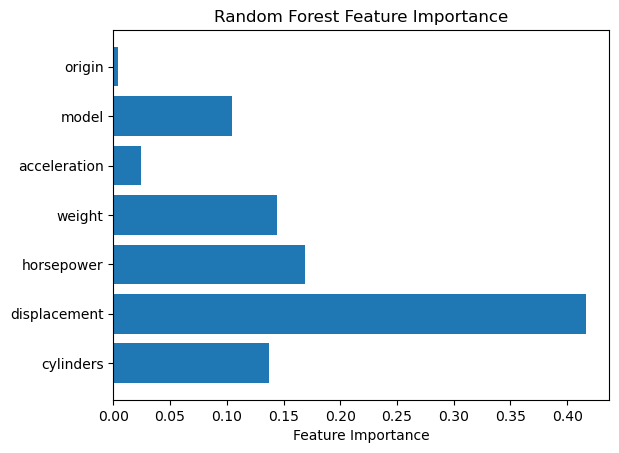

In [58]:
plt.barh(X.columns, importance)
plt.xlabel('Feature Importance')
plt.title("Random Forest Feature Importance")

plt.show()

In [63]:
indices = np.argsort(importance)[::-1][:5]
important_features = X_train.columns[indices]

print(important_features)

Index(['displacement', 'horsepower', 'weight', 'cylinders', 'model'], dtype='object')


In [64]:
model.fit(X_train[important_features], y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [65]:
model.predict(X_test[important_features])

array([25.642, 22.228, 35.702, 30.9  , 27.21 , 27.04 , 12.58 , 28.448,
       19.405, 31.893, 14.11 , 20.089, 16.239, 26.135, 19.154, 29.917,
       19.987, 33.25 , 28.271, 31.357, 21.235, 38.294, 33.91 , 16.027,
       31.281, 22.54 , 20.26 , 18.346, 28.023, 23.61 , 14.88 , 19.961,
       21.026, 30.133, 13.14 , 34.378, 13.735, 27.59 , 15.31 , 11.65 ,
       14.615, 28.724, 34.202, 25.869, 14.72 , 11.59 , 17.275, 35.189,
       23.569, 31.808, 14.405, 23.548, 23.275, 34.208, 28.021, 16.918,
       17.699, 19.082, 24.11 , 24.586, 11.92 , 20.059, 25.808, 21.606,
       26.835, 26.677, 25.318, 31.738, 19.859, 13.38 , 24.069, 13.22 ,
       22.288, 26.858, 24.653, 26.37 , 13.57 , 17.162, 26.915])

In [66]:
mean_squared_error(y_test, model.predict(X_test[important_features]))

6.553671189873417